In [2]:
import os
import json
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [17]:
def h5_value_to_python(v):
    """
    Convert HDF5 attribute values to normal Python values.
    """
    if isinstance(v, bytes):
        return v.decode()

    if isinstance(v, np.generic):
        return v.item()

    if isinstance(v, np.ndarray):
        if v.shape == ():
            return v.item()
        return v.tolist()

    return v

def flatten_config(config):
    """
    Converts a nested JSON dictionary into a flat dictionary.

    Example:
        config["params"]["alpha"] -> flat["alpha"]
        config["domain"]["Lx"]    -> flat["Lx"]
    """
    flat = {}

    for group, values in config.items():
        if isinstance(values, dict):
            for key, value in values.items():
                flat[key] = value
        else:
            flat[group] = values

    return flat


params = ["alpha", "beta", "chi", "v0", "D_r", "ended"]

### GET THE PARAMETERS FROM JSON

def read_json_parameters(sim_dir, params=params):
    """
    Read selected simulation parameters from the JSON file inside sim_dir.
    The JSON is flattened so parameters can be accessed directly by name.
    """

    json_files = [f for f in os.listdir(sim_dir) if f.endswith(".json")]

    if not json_files:
        return {}

    json_path = os.path.join(sim_dir, json_files[0])

    with open(json_path, "r") as f:
        config = json.load(f)

    flat_config = flatten_config(config)

    out = {}

    for p in params:
        out[p] = flat_config.get(p, None)

    return out


def read_simulation_parameters(f):
    """
    Read only simulation/model parameters from the HDF5 file.
    Ignores grid/domain metadata such as Nx, Ny, Lx, Ly.
    """

    metadata = {}

    groups_to_read = ["params", "beads"]

    for group_name in groups_to_read:
        if group_name not in f:
            continue

        group = f[group_name]

        for k, v in group.attrs.items():
            metadata[k] = h5_value_to_python(v)
            metadata[f"{group_name}.{k}"] = h5_value_to_python(v)

    return metadata


def standardize_metadata(metadata):
    """
    Optional: create short column names used by your plotting functions.

    Adjust this depending on how your metadata is saved.
    """

    aliases = {
        "beads.N_bd": "nb",
        "grid.Nbd": "nb",
        "Nbd": "nb",
        "Nb": "nb",

        "beads.m_bd": "rbm",
        "m_bd": "rbm",
        "rm": "rbm",

        "beads.sig_bd": "sig",
        "sig_bd": "sig",
        "sigma": "sig",

        "params.D_psi": "dpsi",
        "D_psi": "dpsi",
        "Dpsi": "dpsi",

        "params.rq": "rq",
        "params.v0": "v0",

        "beads.dist": "dist",
    }

    out = dict(metadata)

    for old, new in aliases.items():
        if old in out and new not in out:
            out[new] = out[old]

    return out


def analyze_h5(h5_path, t=-1):
    with h5py.File(h5_path, "r") as f:
        psi = f["solution/psi_hist"][t]
        qx = f["solution/qx_hist"][t]
        qy = f["solution/qy_hist"][t]
        Nb = f["grid"].attrs["Nbd"]
        x = f["grid/x"][:]
        y = f["grid/y"][:]    


    qmag = np.sqrt(qx**2 + qy**2)
    area_q = np.mean(qmag)
    m = 0.5 * (np.clip(psi, -1, 1) + 1)
    s = -0.5 * (np.clip(psi, -1, 1) - 1)
    xcm_m = np.round(np.mean(x * m) / np.mean(m), 2)
    ycm_m = np.round(np.mean(y * m) / np.mean(m), 2)
    xcm_s = np.round(np.mean(x * s) / np.mean(s), 2)
    ycm_s = np.round(np.mean(y * s) / np.mean(s), 2)
    area_m = np.round(np.mean(m), 2)
    area_s = np.round(np.mean(s), 2)

    return {
        "Nb": Nb,
        "area_m": area_m,
        "area_s": area_s,
        "cm_m": (xcm_m, ycm_m),
        "cm_s": (xcm_s, ycm_s),
        "area_q": area_q,
        "max_psi": np.max(psi),
        "has_diff": np.any(psi > 0.9),
    }


def scan(base_dir, t=-1, params=params):
    rows = []

    for root, dirs, files in os.walk(base_dir):
        h5_files = [f for f in files if f.endswith(".h5")]

        for h5_file in h5_files:
            h5_path = os.path.join(root, h5_file)

            try:
                obs = analyze_h5(h5_path, t=t)
            except Exception as e:
                print(f"Skipping {h5_path}: {e}")
                continue

            metadata = read_json_parameters(root, params=params)

            row = {
                "h5_path": h5_path,
                "sim_folder": os.path.basename(root),
                "param_folder": os.path.basename(os.path.dirname(root)),
            }

            row.update(metadata)
            row.update(obs)

            rows.append(row)

    return pd.DataFrame(rows)


def plot_area_vs_nb(df, rq, v0, y="area_psi"):
    # Filter dataset
    df_sub = df[(df["rq"] == rq) & (df["v0"] == v0)]

    if df_sub.empty:
        raise ValueError("No data for given rq and v0")

    # Group by number of beads
    grouped = df_sub.groupby("nb")[y].mean()

    # fig, ax = plt.subplots(figsize=(5, 4))

    ax.plot(
        grouped.index,
        grouped.values,
        "o-", 
        label=f"rq={rq}, v0={v0}"
    )

    # return fig, ax



def plot_vs(df, xparam, y="area_psi"):
    grouped = df.groupby(xparam)[y]

    mean = grouped.mean()
    std = grouped.std()

    fig, ax = plt.subplots(figsize=(5, 4))

    ax.errorbar(
        mean.index,
        mean.values,
        yerr=std.values,
        fmt="o-",
        capsize=3,
    )

    ax.set_xlabel(xparam)
    ax.set_ylabel(y)
    ax.grid()
    ax.set_ylim(-0.1, 1.1)

    return fig, ax


def print_available_parameters(df):
    """
    Print unique values available for each parameter column.
    """

    # Columns you want to ignore
    ignore = {
        "param_folder",
        "sim_folder",
        "h5_path",
        "area_psi",
        "area_q",
        "max_psi",
        "has_diff",
        "diff",
    }

    # Candidate parameter columns
    param_cols = [c for c in df.columns if c not in ignore]

    print("=" * 50)

    for col in sorted(param_cols):

        # Remove NaNs and sort values
        vals = sorted(df[col].dropna().unique())

        print(f"{col}:")
        print(vals)
        print()

    print("=" * 50)



def plot_binary_phase_scatter(df, x, y, fixed=None, ax=None):
    """
    Binary phase diagram using scatter points.

    diff = True  -> differentiated
    diff = False -> not differentiated
    """

    d = df.copy()

    # Apply fixed parameter filters
    if fixed is not None:
        for k, v in fixed.items():
            d = d[d[k] == v]

    if d.empty:
        raise ValueError("No data after filtering")

    # Separate differentiated / non differentiated
    d_true = d[d["has_diff"] == True]
    d_false = d[d["has_diff"] == False]

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    else:
        fig = ax.figure

    # Differentiated
    from matplotlib.colors import LogNorm

    cvals = d_true["area_psi"].values

    # avoid non-positive values for log scale by finding smallest positive value
    positive = cvals[cvals > 0]
    if positive.size >= 0:
        vmin = positive.min()
    else:
        vmin = 1e-6

    vmax = max(cvals.max(), vmin)
    # norm = LogNorm(vmin=vmin, vmax=1)

    # Non differentiated
    ax.scatter(
        d_false[x],
        d_false[y],
        marker="x",
        s=80,
        color="red",
        label="No differentiation"
    )

    # Differentiated
    cm = ax.scatter(
        d_true[x],
        d_true[y],
        marker="o",
        s=80,
        label="Differentiated",
        c=cvals,
        cmap="viridis"
        # norm=norm,
    )


    cbar = fig.colorbar(cm, ax=ax)
    cbar.set_label("Area of psi")
    if fixed is not None:
        title = ", ".join([f"{k}={v}" for k, v in fixed.items()])
        ax.set_title(title)

    ax.grid()
    # ax.legend()

    return fig, ax

# Beads no dynamics

In [25]:
base_dir = "outputs/differentiation_sweep/"

params = ["type", "x0", "sigma"]
df = scan(base_dir, params=params)

display(df)

print_available_parameters(df)

# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)

df.to_csv("memory_models.differentiation_sweep")

pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

,h5_path,sim_folder,param_folder,type,x0,sigma,t_dec,Nb,area_m,area_s,cm_m,cm_s,area_q,max_psi,has_diff
0,outputs/differentiation_sweep/dist_pol_sig_0.5...,sim_data_20260601_164419,dist_pol_sig_0.5_rbm_0.1_x0_25.0_dpsi_1.0,pol,25.0,0.5,50.0,0.157080,0.00,1.00,"(25.0, 25.0)","(24.9, 24.9)",0.0,-1.0,False
1,outputs/differentiation_sweep/dist_pol_sig_0.5...,sim_data_20260609_113852,dist_pol_sig_0.5_rbm_0.1_x0_25.0_dpsi_1.0,pol,25.0,0.5,50.0,0.157080,0.00,1.00,"(25.0, 25.0)","(24.87, 24.87)",0.0,-1.0,False
2,outputs/differentiation_sweep/dist_pol_sig_4.0...,sim_data_20260605_063046,dist_pol_sig_4.0_rbm_0.9_x0_25.0_dpsi_20.0,pol,25.0,4.0,50.0,90.477868,0.00,1.00,"(25.0, 25.0)","(24.87, 24.87)",0.0,-1.0,False
3,outputs/differentiation_sweep/dist_pol_sig_20....,sim_data_20260603_114028,dist_pol_sig_20.0_rbm_0.5_x0_25.0_dpsi_1.0,pol,25.0,20.0,50.0,781.660305,1.00,0.00,"(24.8, 24.8)","(24.78, 24.78)",0.0,1.0,True
4,outputs/differentiation_sweep/dist_pol_sig_25....,sim_data_20260603_120127,dist_pol_sig_25.0_rbm_0.9_x0_25.0_dpsi_3.0,pol,25.0,25.0,50.0,1647.161963,1.00,0.00,"(24.8, 24.8)","(24.79, 24.79)",0.0,1.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3305,outputs/differentiation_sweep/dist_pol_sig_4.5...,sim_data_20260605_072009,dist_pol_sig_4.5_rbm_0.4_x0_25.0_dpsi_7.0,pol,25.0,4.5,50.0,50.893798,0.00,1.00,"(24.88, 24.88)","(24.87, 24.87)",0.0,-1.0,False
3306,outputs/differentiation_sweep/dist_pol_sig_20_...,sim_data_20260521_172411,dist_pol_sig_20_rbm_0.7_x0_25.0_dpsi_5.0,pol,25.0,20.0,50.0,1094.324427,1.00,0.00,"(24.8, 24.8)","(24.8, 24.8)",0.0,1.0,True
3307,outputs/differentiation_sweep/dist_pol_sig_3.5...,sim_data_20260630_124500_it_957220519,dist_pol_sig_3.5_rbm_0.5_x0_25.0_dpsi_10.0,pol,25.0,3.5,50.0,38.484510,0.00,1.00,"(24.8, 24.8)","(24.8, 24.8)",0.0,-1.0,False
3308,outputs/differentiation_sweep/dist_pol_sig_3.5...,sim_data_20260605_034611,dist_pol_sig_3.5_rbm_0.5_x0_25.0_dpsi_10.0,pol,25.0,3.5,50.0,38.484510,0.00,1.00,"(24.9, 24.9)","(24.88, 24.88)",0.0,-1.0,False


Nb:
[np.float64(0.15707963267948966), np.float64(0.15707963267949532), np.float64(0.3141592653589793), np.float64(0.31415926535899064), np.float64(0.47123889803846897), np.float64(0.47123889803848606), np.float64(0.6283185307179586), np.float64(0.6283185307179813), np.float64(0.7853981633974483), np.float64(0.7853981633974484), np.float64(0.7853981633974766), np.float64(0.9424777960769379), np.float64(0.9424777960769721), np.float64(0.942477806162536), np.float64(1.0995574287564274), np.float64(1.0995574287564276), np.float64(1.0995574287564673), np.float64(1.099557440522959), np.float64(1.2566370614359172), np.float64(1.2566370614359625), np.float64(1.2566370748833815), np.float64(1.4137166941154067), np.float64(1.4137166941154071), np.float64(1.4137166941154582), np.float64(1.4137167092438045), np.float64(1.5707963267948966), np.float64(1.5707963267948968), np.float64(1.5707963267949532), np.float64(1.5707963436042267), np.float64(1.8849555921538756), np.float64(1.8849555921538759), 

In [16]:
from scipy.integrate import quad


def f(psi, rm):
    output = (0.25 * (psi**2 - 1)**2 - rm * psi * (1 - psi/2))
    return output

def integrand(psi, rm):
            return np.sqrt(np.abs(f(psi, rm)))


rc = 0.25
rm_arr = np.linspace(0.0, 1.0, 100)

def compute_sig_teo(rm_arr, rc, D):
    sig_arr = []

    for rm in rm_arr:
        integral, _ = quad(integrand, -1, 1, args=(rm,))
        aux = np.sqrt(D) * integral / (rm * np.log(rm / rc) ** (1/2))
        sig_arr.append(aux)
    return np.array(sig_arr)

/tmp/ipykernel_43747/4086930683.py:20: RuntimeWarning: divide by zero encountered in log
  aux = np.sqrt(D) * integral / (rm * np.log(rm / rc) ** (1/2))
/tmp/ipykernel_43747/4086930683.py:20: RuntimeWarning: invalid value encountered in scalar multiply
  aux = np.sqrt(D) * integral / (rm * np.log(rm / rc) ** (1/2))
/tmp/ipykernel_43747/4086930683.py:20: RuntimeWarning: invalid value encountered in scalar power
  aux = np.sqrt(D) * integral / (rm * np.log(rm / rc) ** (1/2))


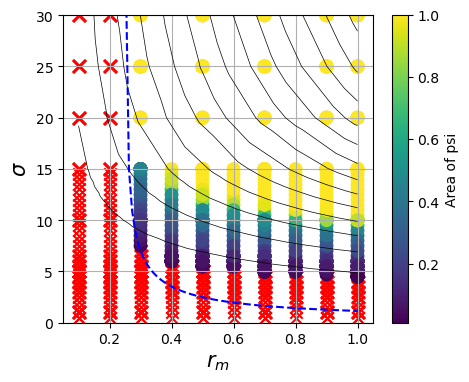

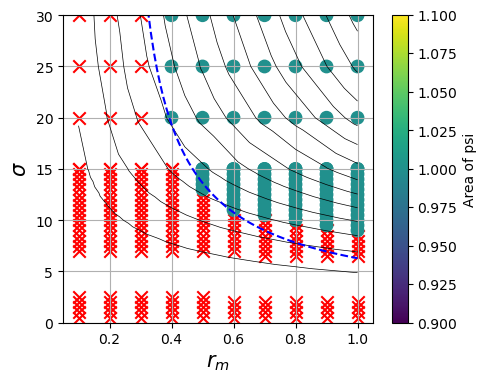

In [ ]:
params = ["alpha", "beta", "chi", "v0", "D_r", "ended"]

fixed = {
        "D_psi": 1.0,
        }

fig, ax = plt.subplots(figsize=(5, 4))
plot_binary_phase_scatter(
    df,
    x="rbm",
    y="sigma",
    fixed=fixed,
    ax=ax
)def plot_vs_fixed(df, xparam, fixed=None, y="area_psi", ax=None):
    """
    Plot mean y versus xparam, fixing arbitrary parameters.

    Example:
    plot_vs_fixed(df, "nb", fixed={"rq": 1.0, "v0": 3.0})
    """

    if fixed is None:
        fixed = {}

    df_sub = df.copy()

    for key, value in fixed.items():
        df_sub = df_sub[df_sub[key] == value]

    if df_sub.empty:
        raise ValueError(f"No data for fixed parameters: {fixed}")

    grouped = df_sub.groupby(xparam)[y].mean().sort_index()

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    else:
        fig = ax.figure

    label = ", ".join([f"{k}={v}" for k, v in fixed.items()])

    ax.plot(
        grouped.index,
        grouped.values,
        "o-",
        label=label
    )

    ax.set_xlabel("integral rb")
    ax.set_ylabel(y)
    ax.legend()

    return fig, ax

d = df.copy()
d=d[d["x0"] == 25.0]
sig = d["sigma"].values
rbm = d["rbm"].values
Nb = d["Nb"].values
ax.tricontour(rbm, sig, Nb, levels=14, linewidths=0.5, colors='k')
plt.xlim(0.05, 1.05)
plt.ylim(0.0, 30.05)
ax.set_xlabel(r"$r_m$", fontsize=15)
ax.set_ylabel(r"$\sigma$", fontsize=15)
plt.title("")
plt.savefig("phase_diagram_gauss_dpsi_1.png", dpi=300, bbox_inches="tight")


sig_arr = compute_sig_teo(rm_arr, rc, 1.0)
ax.plot(rm_arr, sig_arr, 'b--', label='Analytical Transition Curve')

# add_binary_transition_curve(ax, df, fixed, x="rbm", y="sigma", eps=1e-2, value="area_psi")


fixed = {
        "D_psi": 30.0,
        }

fig, ax = plt.subplots(figsize=(5, 4))
plot_binary_phase_scatter(
    df,
    x="rbm",def plot_vs_fixed(df, xparam, fixed=None, y="area_psi", ax=None):
    """
    Plot mean y versus xparam, fixing arbitrary parameters.

    Example:
    plot_vs_fixed(df, "nb", fixed={"rq": 1.0, "v0": 3.0})
    """

    if fixed is None:
        fixed = {}

    df_sub = df.copy()

    for key, value in fixed.items():
        df_sub = df_sub[df_sub[key] == value]

    if df_sub.empty:
        raise ValueError(f"No data for fixed parameters: {fixed}")

    grouped = df_sub.groupby(xparam)[y].mean().sort_index()

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    else:
        fig = ax.figure

    label = ", ".join([f"{k}={v}" for k, v in fixed.items()])

    ax.plot(
        grouped.index,
        grouped.values,
        "o-",
        label=label
    )

    ax.set_xlabel("integral rb")
    ax.set_ylabel(y)
    ax.legend()

    return fig, ax
    y="sigma",
    fixed=fixed,
    ax=ax
)

d = df.copy()
d=d[d["x0"] == 25.0]
sig = d["sigma"].values
rbm = d["rbm"].values
Nb = d["Nb"].values
ax.tricontour(rbm, sig, Nb, levels=14, linewidths=0.5, colors='k')
plt.xlim(0.05, 1.05)
plt.ylim(0.0, 30.05)
ax.set_xlabel(r"$r_m$", fontsize=15)
ax.set_ylabel(r"$\sigma$", fontsize=15)
plt.title("")

sig_arr = compute_sig_teo(rm_arr, rc, 30.0)
ax.plot(rm_arr, sig_arr, 'b--', label='Analytical Transition Curve')

# add_binary_transition_curve(ax, df, fixed, x="rbm", y="sigma", eps=1e-2, value="area_psi")
plt.savefig("phase_diagram_gauss_dpsi_30.png", dpi=300, bbox_inches="tight")


# Dynamics no q

In [26]:
base_dir = "outputs/dyn_no_q_sweep"

params = ["rbm", "x0", "lam_p", "v0", "t_dec", "noise_mag"]

df = scan(base_dir, params=params)
display(df)

print_available_parameters(df)


,h5_path,sim_folder,param_folder,rbm,x0,lam_p,v0,t_dec,noise_mag,Nb,area_m,area_s,cm_m,cm_s,area_q,max_psi,has_diff
0,outputs/dyn_no_q_sweep/sim_data_20260702_13081...,sim_data_20260702_130815_it_900894646,dyn_no_q_sweep,0.26,25.0,0.10,0.1,50.0,1.00,475.838027,0.04,0.96,"(25.0, 25.0)","(24.74, 24.74)",0.0,0.996465,True
1,outputs/dyn_no_q_sweep/sim_data_20260702_12003...,sim_data_20260702_120037_it_36948148,dyn_no_q_sweep,0.78,12.5,10.00,10.0,10.0,0.10,434.998998,0.21,0.79,"(9.58, 9.58)","(28.78, 28.78)",0.0,1.000000,True
2,outputs/dyn_no_q_sweep/sim_data_20260702_11562...,sim_data_20260702_115626_it_1564627359,dyn_no_q_sweep,0.78,12.5,0.10,10.0,10.0,0.10,434.998998,0.21,0.79,"(9.57, 9.57)","(28.79, 28.79)",0.0,1.000000,True
3,outputs/dyn_no_q_sweep/sim_data_20260702_11202...,sim_data_20260702_112026_it_1928649627,dyn_no_q_sweep,0.78,12.5,0.01,1.0,20.0,0.01,434.998998,0.32,0.68,"(11.66, 11.66)","(30.86, 30.86)",0.0,1.000006,True
4,outputs/dyn_no_q_sweep/sim_data_20260702_11333...,sim_data_20260702_113336_it_1952416956,dyn_no_q_sweep,0.78,12.5,1.00,10.0,10.0,0.01,434.998998,0.21,0.79,"(9.58, 9.58)","(28.78, 28.78)",0.0,1.000000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,outputs/dyn_no_q_sweep/sim_data_20260702_12461...,sim_data_20260702_124611_it_2126900715,dyn_no_q_sweep,0.26,25.0,5.00,10.0,10.0,0.01,475.838027,0.00,1.00,"(24.75, 24.75)","(24.75, 24.75)",0.0,-1.000000,False
476,outputs/dyn_no_q_sweep/sim_data_20260702_13052...,sim_data_20260702_130523_it_1998417599,dyn_no_q_sweep,0.26,25.0,1.00,10.0,100.0,0.10,475.838027,1.00,0.00,"(24.79, 24.79)","(11.9, 11.9)",0.0,1.000000,True
477,outputs/dyn_no_q_sweep/sim_data_20260702_13273...,sim_data_20260702_132733_it_184091362,dyn_no_q_sweep,0.26,25.0,10.00,10.0,50.0,1.00,475.838027,0.04,0.96,"(25.0, 25.0)","(24.74, 24.74)",0.0,0.997325,True
478,outputs/dyn_no_q_sweep/sim_data_20260702_12442...,sim_data_20260702_124420_it_1207767636,dyn_no_q_sweep,0.26,25.0,1.00,10.0,10.0,0.01,475.838027,0.00,1.00,"(24.75, 24.75)","(24.75, 24.75)",0.0,-1.000000,False


Nb:
[np.float64(434.99899838113754), np.float64(475.83802659453886)]

area_m:
[np.float64(0.0), np.float64(0.03), np.float64(0.04), np.float64(0.05), np.float64(0.06), np.float64(0.07), np.float64(0.1), np.float64(0.21), np.float64(0.32), np.float64(0.54), np.float64(0.67), np.float64(0.99), np.float64(1.0)]

area_s:
[np.float64(0.0), np.float64(0.01), np.float64(0.33), np.float64(0.46), np.float64(0.68), np.float64(0.79), np.float64(0.9), np.float64(0.93), np.float64(0.94), np.float64(0.95), np.float64(0.96), np.float64(0.97), np.float64(1.0)]

cm_m:
[(np.float64(9.57), np.float64(9.57)), (np.float64(9.58), np.float64(9.58)), (np.float64(9.59), np.float64(9.59)), (np.float64(11.66), np.float64(11.66)), (np.float64(11.68), np.float64(11.68)), (np.float64(14.37), np.float64(14.37)), (np.float64(16.8), np.float64(16.8)), (np.float64(24.75), np.float64(24.75)), (np.float64(24.79), np.float64(24.79)), (np.float64(24.87), np.float64(24.87)), (np.float64(24.99), np.float64(24.99)), (np.float